# Simulating Quantum Capacitance of Graphene  


In this Jupyter tool, we aim to simulate the quantum capacitance  ($C_q$) [1] of graphene and compare the results with experimental values. 

It consists Three distinct parts, viz., (1) Discussion of basic theory of quantum capacitance, (2) Calculating  the density of states (DOS) of graphene with SIESTA code [2], and (3) Obtaining $C_q$ from the DOS using standard ptyhon3 scripts. Variation of $C_q$ and temperature etc. were also discussed in detail.

Note that the SIESTA code is available via $Nanohub$ program (see: https://nanohub.org/resources/siesta ), and we strongly recommend to use this to obtain the density of states of graphene.


#### Some Important Parameters etc. are given below:

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

kB = 8.62*10**-5 # Boltzmann Constant in eV/K

## Part-1: Basic Theory of $C_q$

Quantum capacitance plays an important role in Nanoelectronics and in supercapacitors. Nanoelectronic devices are electronic components with dimensions usually ranging from 1 nm to 100 nm, where their behaviour is largely influenced by *quantum mechanical effects*. Examples include advanced transistors such as FinFETs, as well as memristors and nanowires. These technologies make it possible to create electronics that are smaller, faster, and more energy-efficient, with important applications in advanced memory systems, artificial intelligence hardware, and sensing technologies.

We know that, in macroscopic domain, we usually deals with *geometric* or *dielectric* capacitance (in practice, we use 
micro-Farad unit for these devices). So, When will one has to use Quantum Capacitance? The answer is clearly mentioned in the book [3], and it says (especially in nanoscale MOSFETs): *"Because the quantum capacitance is small compared with the double-layer capacitance, it dominates the total interfacial capacitance..."* This can be easily interpreted by the following figure:






<img src="Ctotal.png" />


From the basic theory of capacitors one can interpret the MOSFET's 'Gate' capacitor (that is composed of dielectric capacitor and quantum capacitance (due to graphene))
$$
\frac{1}{C_{\text{total}}}
=
\frac{1}{C_{DL}}
+
\frac{1}{C_{Q}}
$$

$$
C_{\text{total}}
=
\frac{C_{DL}\, C_{Q}}{C_{DL} + C_{Q}}
$$

From the above table, we can seen that in a series connection, the total capacitance is always less than the smallest individual capacitance-component in the circuit - it is crucial in nano-regime - since $C_Q < C_{DL}$ , the total capacitance is lesser than $C_Q$ (in other words, $C_q$ become a limiting factor in the total capacitance.).

<img src="graphene-fet.png" />

For more details on CNT/graphene based fabrications of nanosized devices see Ref [4].

## Part-2: Calculating Density of States (DOS) of Graphene with SIESTA

Here, we used SIESTA (Spanish Initiative for Electronic Structure Simulations with Thousands of Atoms) code that use density functional theory (DFT) to solve Schrodinger equation of Graphene to obtain DOS. SIESTA uses localized numerical atomic orbital type basis set to solve Schrodinger equation to calculate DOS.
We use a simple 1x1 supercell cell, GGA functional, spin-polarized and DZP type basis settings. The 'Lattice Parameter' was chosen 2.46 Angstrom as it is close to the experimental lattice constant

The important parameters for SIESTA are:


$$
\begin{aligned}
& \text {Table 1.1. Important SIESTA parameters }\\
&\begin{array}{cccc}
\hline \hline \text { Parameters } & \text { Value }  \\
\hline Basis set & DZP  \\
DFT Level & GGA (PBE functional)  \\
K-point & 96 \times96\times1 (Monkhorst-Pack \quad grid)  \\
Spin-polarized & Yes  \\
Meshcutoff & 200 Ry. \\
\hline
\end{array}
\end{aligned}
$$

See Appendix-A for the unitcell specification of 1x1 Unitcell, which is required for the SIESTA input file.

#### <u>  Procedure - 1 : Running SIESTA for DOS</u> 
Launch Siesta and add parameters/data as shown in the below figures:

1. <img src="1.png" />

2. <img src="2.png" />

3. <img src="3.png" />

4. <img src="4.png" />

5. <img src="5.png" />

6. <img src="6.png" />

After this press <Run> button to simulate; If everything went fine, the screen will show the remark: **Running Siesta**

After Completing, the tool will displays many output data including Total-DOS as shown below (an additional inset figure displays VB/CB separation of DOS). Furthermore one can also
extract the numerical values from the graph:




<img src="dossmallfinal.png" />




From this graph we can extract numerical values of DOS (use the Green Download button near the Top-Right Corner);

Save this E and DOS values and make it an array for the Polynomial fitting (as it is shown in the *Procedure-2*). Using this we can approximately represents DOS(E) as an *Analytical function* which can be used to get $C_q$.

DOS has many properties like:

$$ \int_{-\infty}^{+\infty} DOS(E)\, dE 
= \text{Number of bands per k-point} 
= \text{Number of atomic orbitals in the unit cell}
\
$$

$$
\int_{-\infty}^{+\infty} DOS(E)\, n(E)\, dE 
= \text{Number of electrons in the unit cell}
\
$$
where $n(E)$ is the Occupation factor at energy E, determined by FD distribution (this second expression can be used to normalize the DOS if it is necessary).

#### <u> Procedure - 2:  Polynomial Fitting of DOS</u>


From the Total DOS data one can easily extract DOS(E), say from -1.0 eV to +1.0 eV, approximately:

In [2]:
E=[-1.055276, -0.954774,  -0.854271,  -0.753769,  -0.653266,  -0.552764,  -0.452261,  -0.351759,  -0.251256,  -0.150754,  
-0.050251,   0.050251,   0.150754,   0.251256,   0.351759,   0.452261,   0.552764,   0.653266,   0.753769,   0.854271,   0.954774,   1.055276]  
dosE=  [ 0.124795,   0.110198,   0.097993,   0.085524,   0.073122,   0.061935,   0.050007,   0.038946,   0.027857,   0.016594,
   0.007813,   0.007854,   0.016834,   0.028451,   0.040159,   0.052059,   0.065168,   0.078003,   0.092359,   0.107995,    0.12368,   0.143881]


#### (Sometimes overfitting is Really useful! An easy way to get 'interpolate' between the data points:)
And note by increasing k-point grid one can increase the quality of the Fitted function, say by using (256 x 256 x 1) Monkhorst-Pack setting (though it will take more time for SIESTA simulation).

In [3]:
# Calculate the polynomial fit coefficients

x=E
y=dosE
degree = 10 # (Guess What will be the Graph if: degree=20 ? )
coefficients = np.polyfit(x, y, degree) #

# Create a polynomial function from the coefficients
polynomial_function = np.poly1d(coefficients)

# Generate points for the fitted curve
# Create a smooth range of x values for the curve
x_curve = np.linspace(min(x), max(x), 100)
# Evaluate the polynomial at these points
y_curve = polynomial_function(x_curve)

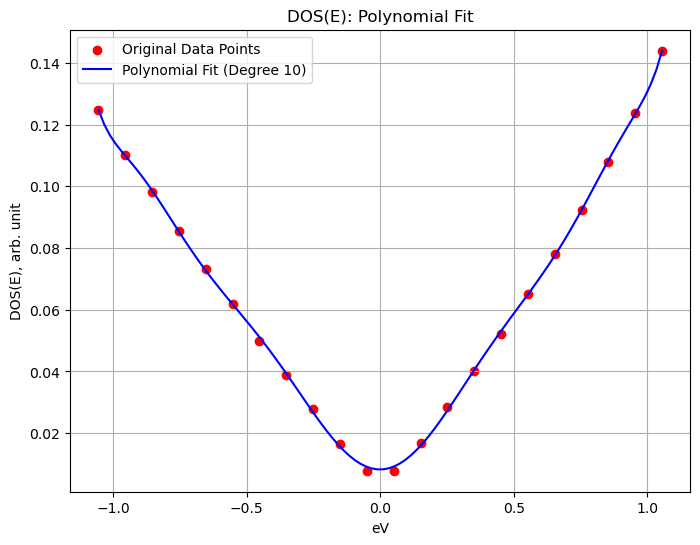

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='red', label='Original Data Points')
plt.plot(x_curve, y_curve, color='blue', label=f'Polynomial Fit (Degree {degree})')
plt.title('DOS(E): Polynomial Fit')
plt.xlabel('eV')
plt.ylabel('DOS(E), arb. unit')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
print("Coefficients:", coefficients)
DOS_E = np.poly1d(coefficients)
print("Polynomial DOS(E) Function:\n", DOS_E)



Coefficients: [ 5.23390991e-01  2.02978595e-03 -1.59455653e+00 -1.72719285e-03
  1.81928179e+00 -4.42181660e-04 -9.86520629e-01  7.24595774e-03
  3.52935318e-01  7.78425938e-04  8.21734054e-03]
Polynomial DOS(E) Function:
         10           9         8            7         6             5
0.5234 x  + 0.00203 x - 1.595 x - 0.001727 x + 1.819 x - 0.0004422 x
           4            3          2
 - 0.9865 x + 0.007246 x + 0.3529 x + 0.0007784 x + 0.008217


#### Evaluate the Polynomial f(x)

In [6]:
DOS_E(0.5).item() # to get pure pythonic-Float

0.058773906575559295

## Part-3:  $C_q$ from the DOS

In Part-2 we have obtained the DOS as an analytical function, in terms of the polynomial that can be used to calculate $C_q$.
The $C_q$ is defined, for example following S. Datta, [2] as:

\begin{align}
C_q &= \frac{d\sigma}{d\phi_E} \\[6pt]
C_q &= e^2 \int_{-\infty}^{+\infty} D(E)\, F_T(E - \mu)\, dE \\[6pt]
F_T(E - \mu) &= \frac{1}{4kT} \,\text{sech}^2 \left( \frac{E - \mu}{2kT} \right)
\end{align}

In the above expression, $d\sigma$ and $d\phi_E $ are the differential of charge
density and local potential, respectively ($e$ is the charge of an electron, $\mu$ the chemical potential, $D$ is DOS(E), and $F_T$ is thermal broadening function (See Appendix), with usual notations). The SI unit of quantum capacitance is, $F/m^2$ (See the Appendix).


To evaluate the integral equation of $C_q$, we need to calculate the area of the unit cell

#### <u> Procedure - 3:  Area of the Unitcell</u>

In [7]:

# Find area of the Unit Cell
u = np.array([1.23,  2.13042, 0.])
v = np.array([1.23, -2.13042, 0.])

# Calculate the cross product
cross_product = np.cross(u, v)
unitcellArea= np.linalg.norm(cross_product)
print("Area of the Unitcell (in ang**2) =", unitcellArea)


Area of the Unitcell (in ang**2) = 5.2408332


#### <u> Procedure - 4:  Numerical Integration</u>

Note that we need to evaluate the integral of the function:

$ D(E)\, F_T(E - \mu)$

Here the FT function can be now defined:

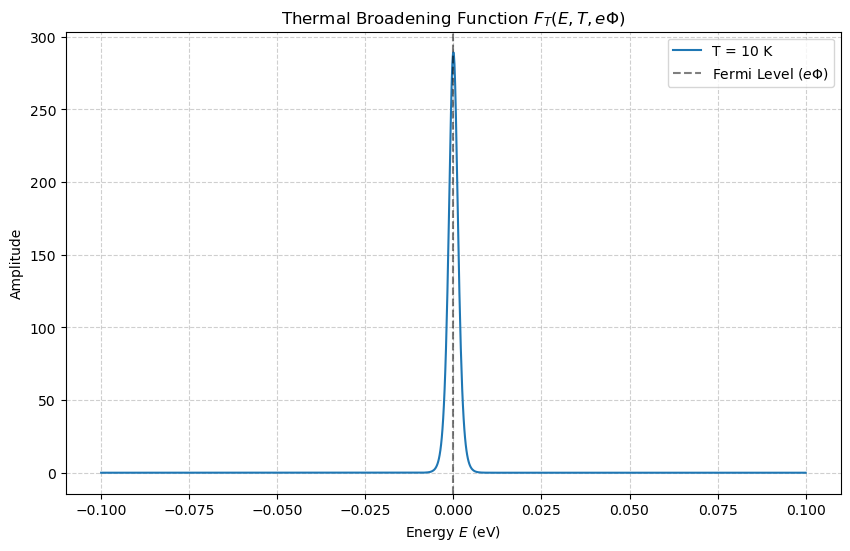

In [9]:
# THERMAL BROADEINING FUNCTION
# TO AVOID OVERFLOW we used the factored-TBF like this
def FT(E,T,ePhi):
    return (1 /( (4*kB*T)*( np.cosh((E-ePhi)/(2*kB*T)))*(np.cosh((E-ePhi)/(2*kB*T)) ) ) ) # Numpy Dont have Sech function

ePhi = 0.0  # Fermi level centered at 0 eV
E = np.linspace(-0.1, 0.1, 1000)  # Energy range from -0.1 to 0.1 eV , IMPORTANT:  [-1,1] range gives Overflow warning
                                  # FWHM is like  ~ kB*T (-10*kB*T to +10*kB*T) is safer set for numerical procedures
temperatures = [10]               # Example temperatures in Kelvin

# Create the plot
plt.figure(figsize=(10, 6))

for T in temperatures:
    plt.plot(E, FT(E, T, ePhi), label=f'T = {T} K')

plt.title(r'Thermal Broadening Function $F_T(E, T, e\Phi)$')
plt.xlabel('Energy $E$ (eV)')
plt.ylabel('Amplitude')
plt.axvline(ePhi, color='black', linestyle='--', alpha=0.5, label='Fermi Level ($e\Phi$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

So it is better idea to plot this **integrand** with respect to $\mu$ ie. ($e\Phi$)

Plot of the Integrand:

10


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6420\201664816.py:4: RuntimeWarning: overflow encountered in cosh
  return (1 /( (4*kB*T)*( np.cosh((E-ePhi)/(2*kB*T)))*(np.cosh((E-ePhi)/(2*kB*T)) ) ) ) # Numpy Dont have Sech function
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6420\201664816.py:4: RuntimeWarning: overflow encountered in multiply
  return (1 /( (4*kB*T)*( np.cosh((E-ePhi)/(2*kB*T)))*(np.cosh((E-ePhi)/(2*kB*T)) ) ) ) # Numpy Dont have Sech function


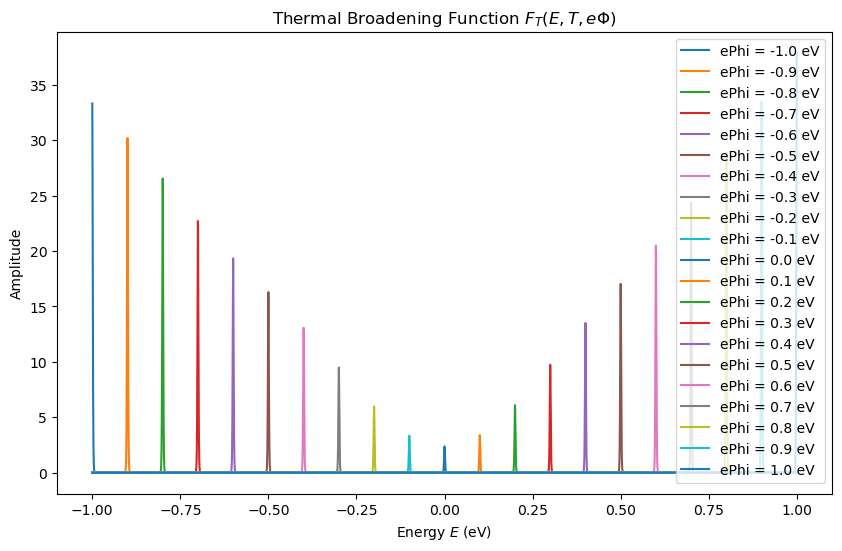

In [10]:
T=10
print(T)

ePhis =  [-1.0,-0.9,-0.8,-0.7,-0.6,-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0 ] # Fermi level centered at 0 eV
E = np.linspace(-1, 1, 10000)  # Energy range from -0.1 to 0.1 eV

# Create the plot
plt.figure(figsize=(10, 6))


for ePhi in ePhis:
    plt.plot(E, DOS_E(E)*FT(E, T, ePhi), label=f'ePhi = {ePhi} eV')

plt.title(r'Thermal Broadening Function $F_T(E, T, e\Phi)$')
plt.xlabel('Energy $E$ (eV)')
plt.ylabel('Amplitude')
#plt.axvline(ePhi, color='black', linestyle='--', alpha=0.0, label='Fermi Level ($e\Phi$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.0)
plt.show()

Note that from the above figure we will get a rough approximation of the values and x-scale range.

Now the Actual calculation:

1.0 10


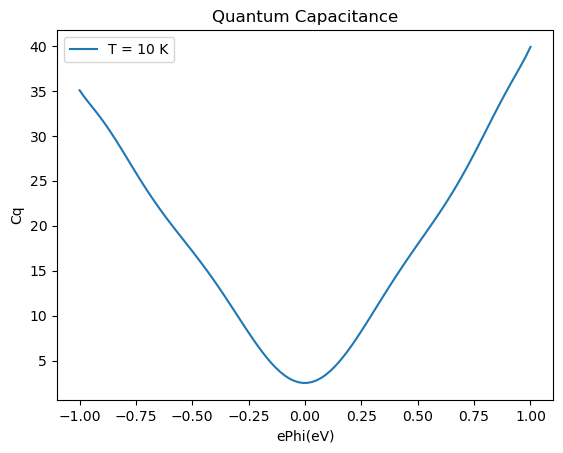

In [13]:
# INTEGRATION for range
T=10
print(ePhi,T)

xePhiPlot = []
yCqPlot = []

ePhis = np.linspace(-1, 1, 100) # Fermi level centered at 0 eV

for ePhi in ePhis:
    # FWHM is like  ~ kB*T (-10*kB*T to +10*kB*T) is safer set for numerical procedures
    E   = np.linspace(-10*kB*T+ePhi, +10*kB*T+ePhi, 1000) # this x-range is reduced to eliminate overflow error
    
    # The Integrand
    y = DOS_E(E)*FT(E, T, ePhi)    
    # compute the definite integral using numpy.trapz()  or numpy.trapz
    integrand = np.trapz(y,dx=(E[999]-E[0])/1000)
    Cq = (1e6*integrand*1.602e-19)/(unitcellArea*1e-16)
    
    #print("For ePhi = %5.2f" % ePhi,"  Qc ( microF/cm2 ) = ",Cq)
    xePhiPlot.append(ePhi)
    yCqPlot.append(Cq)

plt.xlabel('ePhi(eV)')
plt.ylabel('Cq')
#plt.axvline(ePhi, color='black', linestyle='--', alpha=0.0, label='T = ($T$)')
plt.title('Quantum Capacitance')
plt.plot(xePhiPlot,yCqPlot,label=f'T = {T} K')
plt.legend()
plt.show()

1.0 300


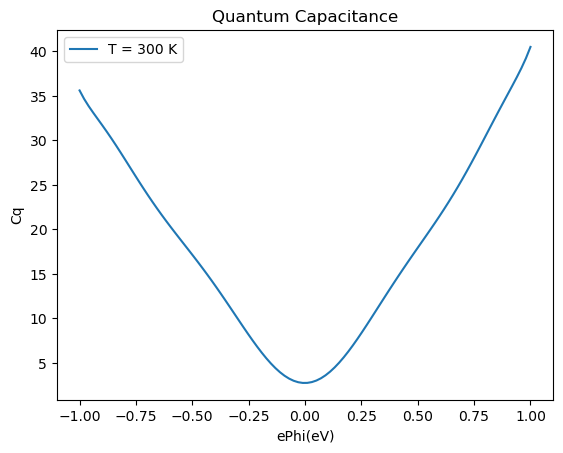

In [14]:
# INTEGRATION for range
T=300
print(ePhi,T)

xePhiPlot = []
yCqPlot300 = []

ePhis = np.linspace(-1, 1, 100)

for ePhi in ePhis:
    # FWHM is like  ~ kB*T (-10*kB*T to +10*kB*T) is safer set for numerical procedures
    E   = np.linspace(-10*kB*T+ePhi, +10*kB*T+ePhi, 1000) # this x-range is reduced to eliminate overflow error
    # The Integrand
    y = DOS_E(E)*FT(E, T, ePhi)    
    # compute the definite integral using numpy.trapz()  or numpy.trapezoid()
    integrand = np.trapz(y,dx=(E[999]-E[0])/1000)
    Cq = (1e6*integrand*1.602e-19)/(unitcellArea*1e-16)
    
    #print("For ePhi = %5.2f" % ePhi,"  Qc ( microF/cm2 ) = ",Cq)
    xePhiPlot.append(ePhi)
    yCqPlot300.append(Cq)

plt.xlabel('ePhi(eV)')
plt.ylabel('Cq')
#plt.axvline(ePhi, color='black', linestyle='--', alpha=0.0, label='T = ($T$)')
plt.title('Quantum Capacitance')
plt.plot(xePhiPlot,yCqPlot300,label=f'T = {T} K')
plt.legend()
plt.show()

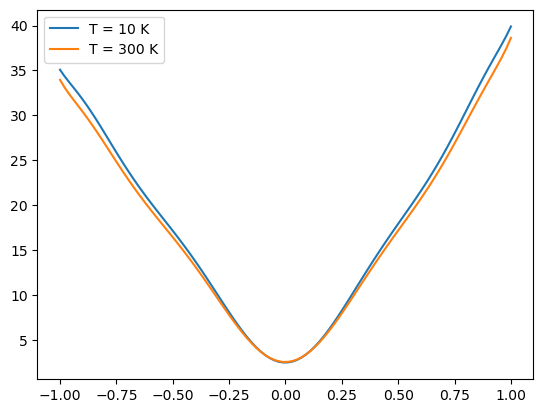

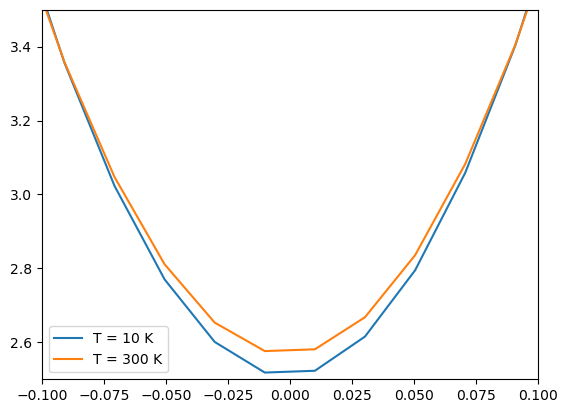

In [35]:
# Combined Cq for two different Temperatures

plt.plot(xePhiPlot,yCqPlot,label=f'T = {10} K')
plt.plot(xePhiPlot,yCqPlot300,label=f'T = {T} K')
plt.legend() # Adds a legend to distinguish lines
plt.show()


# Combined Cq for two different Temperatures But Zoom in near 0eV, ie at center

plt.xlim(-0.1,0.1)
plt.ylim(2.5,3.5)
plt.plot(xePhiPlot,yCqPlot,label=f'T = {10} K')
plt.plot(xePhiPlot,yCqPlot300,label=f'T = {T} K')
plt.legend() # Adds a legend to distinguish lines
plt.show()

The above figure depicts, as experiments, at higher temperatures QC increase slightly only near the center of the chemical potential.

This result match semi- quantitatively with experimental values [5] (See below figure);  **This result can be improved by applying more sophisticated methods and more accurate parameters for SIESTA calculations** - which is assigned as an exercise to the reader.

1. <img src="CqExp.png" />

### Appendix-A: Unitcell of Graphene

The graphene is a honeycomb like lattice (with hexagonal unitcell). as it shown below.

<img src="unitcells.png" />

The above figure shows a honeycomb like lattice (b) which is **4x4 supercell** of a single unit cell
of graphene (a). The unit cell consists of 2 carbon atoms and its bondlength is also shown (the C-E distance in (c), which is about 1.42 Angstrom). Note that the Lattice constant is **|u|=|v|** = 2.46 Angstrom.
We can easily find the unit vectors of this unit cell (u and v) in terms of Cartesian coordinates as below:



\begin{align*}
\vec{u} &= (x_1, \quad y_1, \quad z_1) \\
\vec{v} &= (x_2, \quad y_2, \quad z_2) \\
\vec{w} &= (0,\quad\quad 0,\quad z_3)
\end{align*}

\begin{align*}
\text{First Carbon} &= 0\vec{u} + 0\vec{v}\\[1ex]
\text{Second Carbon} &= \frac{2}{3}\vec{u} + \frac{1}{3}\vec{v} = 0.\overline{6}\vec{u} + 0.\overline{3}\vec{v} \\[1ex]
&= \begin{bmatrix} [\vec{u}] & [\vec{v}] \end{bmatrix} \begin{bmatrix} 0.\overline{6} \\ 0.\overline{3} \end{bmatrix} = \begin{bmatrix} x_{\text{new}} \\ y_{\text{new}} \end{bmatrix} \\[2ex]
&= \begin{bmatrix} x_1 & x_2 \\ y_1 & y_2 \end{bmatrix} \begin{bmatrix} 0.\overline{6} \\ 0.\overline{3} \end{bmatrix}
\end{align*}

\begin{align*}
\implies
\begin{matrix} x_1(0.\overline{6}) + x_2(0.\overline{3}) \\ y_1(0.\overline{6}) + y_2(0.\overline{3}) \end{matrix} = \begin{bmatrix} x_{\text{new}} \\ y_{\text{new}} \end{bmatrix}
\end{align*}






Note that $y_2$ in the above expression is a negative quantity (-2.13042 Å).

The numerical values of $u$, $v$ are given below (that is needed for SIESTA's input file, see *LatticeVectors/AtomicCoordinatesAndAtomicSpecies* ):


$$
\begin{array}{c c c c l l}
 & x & y & z & & \\
\boldsymbol{u} & 1.23000 & 2.13042 & 0.00000 & \text{Lattice Constant}(\boldsymbol{u}) & \mathbf{2.460 Å}  \\
\boldsymbol{v} & 1.23000 & -2.13042 & 0.00000 & \text{Lattice Constant}(\boldsymbol{v}) & \mathbf{2.460 Å} \\
\boldsymbol{w} & 0.00000 & 0.00000 & 10.00000 & \text{Lattice Constant}(\boldsymbol{w}) & \mathbf{10.00 Å} \\
\\
\color{#7030A0}{\boldsymbol{C1}} & \color{#7030A0}{0.00000} & \color{#7030A0}{0.00000} & \color{#7030A0}{0.00000} & & \\
\color{#7030A0}{\boldsymbol{C2}} & \quad \quad \quad  \quad \quad {(2/3)*\boldsymbol{u} + (1/3)*\boldsymbol{v}} & & \\
 & \color{#7030A0}{1.23000} & \color{#7030A0}{0.71014} & \color{#7030A0}{0.00000} & \text{Bond Length (C1-C2)} & \mathbf{1.420 Å} \\
\\
The \quad above \quad (x,y,z) \quad are \quad obtained \quad from:
\\
\boldsymbol{u} & 2.46 \times  \frac{1}{2} & 2.46 \times \frac{\sqrt{3}}{2} & 0.00000 & & \\
\boldsymbol{v} & 2.46 \times \frac{1}{2} & 2.46 \times -\frac{\sqrt{3}}{2}  & 0.00000 & & \\
\end{array}
$$

### Appendix-B: A Sample Siesta Input file

### Appendix-C: Fermi-Dirac Distribution
We know from kinetic theory of gases, the distribution of gas molecules obeys Maxwell-Boltzmann (MB) distribution statistics (for brevity we are not discussing it here). But we cannot apply MB distribution for electrons (eg. in metals) since electrons are Fermion particles which have $\pm \frac{1}{2}$ states (and hence they obey Pauli's exclusion principle), so that an another distribution is needed, which is formulated by Fermi and Dirac (known as FD or Fermi-Dirac distribution).

In [15]:
def FD(En, mu, T):
    return 1/( np.exp((En - mu)/(kB*T)) + 1)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6420\2550753271.py:2: RuntimeWarning: divide by zero encountered in divide
  return 1/( np.exp((En - mu)/(kB*T)) + 1)


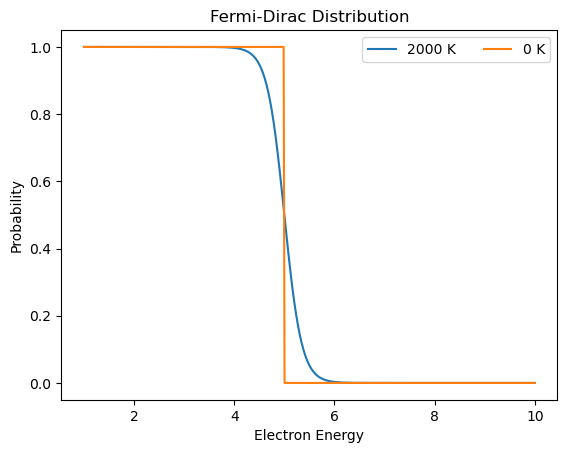

In [17]:
mu=5

T=2000
En = np.linspace(1, 10,500)
plt.plot(En,FD(En,mu,T),label='2000 K')

T=0
plt.plot(En,FD(En,mu,T), label='0 K')

plt.title('Fermi-Dirac Distribution')
plt.legend( ncol=3, loc='upper right')
plt.xlabel('Electron Energy')
plt.ylabel('Probability')

plt.show()


#### Thermal Broadening Function:

Thermal Broadening Function ($F_T$) is used in the calculation of Cq, that is a related to FD function:

We have the FD function,
$$ f(E) = \frac{1}{\exp\!\left(\frac{E - \mu}{kT}\right) + 1}$$
and TBF is defined as: 
$$ - \frac{df}{dE} = - \frac{df}{dx}\frac{dx}{dE} = \frac{1}{kT} \cdot \frac{e^x}{(e^x + 1)^2}, where \quad x = \frac{E - \mu}{kT} \\[6pt]$$
since, $$\cosh(x) = \frac{e^x + e^{-x}}{2}$$ we can write,
\begin{align}
\operatorname \quad {sech}(x) = \frac{1}{\cosh(x)} = \frac{2}{e^x + e^{-x}}, thus \\[6pt]
\operatorname{sech}^2\left(\frac{x}{2}\right)
= \left[\frac{2}{e^{x/2} + e^{-x/2}}\right]^2 = \frac{4}{\left(e^{x/2} + e^{-x/2}\right)^2}\\[6pt] 
Expanding \quad the \quad  denominator \quad yields:
= \frac{4}{e^x + e^{-x} + 2} \\[6pt]
Multiplying \quad numerator \quad  and  \quad denominator \quad by \quad  e^x \quad  gives:
= \frac{4 e^x}{e^{2x} + 1 + 2e^x} \\[6pt]
ie., \quad \operatorname{sech}^2\left(\frac{x}{2}\right)
= \frac{4 e^x}{(e^x + 1)^2} \implies \frac{1}{kT} \cdot \frac{e^x}{(e^x + 1)^2}
&= \frac{1}{4kT} \, \mathrm{sech}^2\!\left(\frac{x}{2}\right)= \frac{1}{4kT} \, \mathrm{sech}^2\!\left(\frac{E - \mu}{2kT}\right) = F_T
\end{align}

### Appendix-D: Units of Quantum Capacitance ($C_q$)

The quantum capacitance is usually expressed, in practical sense: $$\frac{\mu F}{\text{cm}^2} $$

$\begin{align}
&\text{We have:} && C_q = e^2 \int_{-\infty}^{+\infty} DOS(E) F_T(E - e\phi) \, dE \\
&\text{Since the DOS(E) of 2D materials is expressed in: }  \frac{1}{eV \cdot (\mathring{A})^2}, \text{the unit becomes:}\\
& && \equiv e^2 \cdot \frac{1}{eV \cdot (\mathring{A})^2} \cdot \frac{1}{\left(\frac{eV}{K}\right)K} \text{sech}^2 \left( \frac{eV - eV}{\left(\frac{eV}{K}\right)K} \right) \cdot eV \\
& && \equiv e^2 \cdot \frac{1}{eV \cdot (\mathring{A})^2} \cdot \frac{1}{eV} \cdot \text{sech}^2 \left( \frac{eV}{eV} \right) \cdot eV \\
& && \equiv e^2 \cdot \frac{1}{eV(\mathring{A})^2}, \text{ to convert } \mathring{A} \text{ to cm,} \\
& && \equiv e^2 \cdot \frac{1}{eV(10^{-10} \cdot 10^2 \text{ cm})^2} = \frac{e}{V} \times \frac{1}{10^{-16} \text{ cm}^2} \\
& && \equiv \frac{1.6 \times 10^{-27}}{10^{-16}} \left( \frac{C}{V} \right) \cdot \frac{1}{\text{cm}^2} \\
& && \equiv \frac{1.6 \times 10^{-27}}{10^{-16}} \cdot 10^{+6} \left( \frac{\mu F}{\text{cm}^2} \right)
\end{align}$

### Appendix-E: Integrand values

The below figures qualitatively explains the values of $C_q$ when  $e\Phi$ varies from -1.0 to +1.0 eV. The reason is, the integrand function (and hence its area) get expanded if it moves away from | $e\Phi$ | > 0.0 eV. Note that the FT is a distribution function which is not varying in all these figures since its shape is solely depending on $T$ (note the expression, $\frac{1}{4kT}sech^2\frac{E - \mu}{2kT}$). So the function which control the numerical value of  $C_q$  is: DOS(E) !

<img src="integrand.png" />

## References

[1] (a) *Density of States and Zero Landau Level Probed through Capacitance of Graphene*, L.A. Ponomarenko et al., Phys. Rev. Lett. 105, 136801-2010. (b) *Quantum Transport*, S. Datta, Cambridge University Press 2005.

[2] (a) *Siesta: Recent Developments and Applications*, Alberto García et al., J. Chem. Phys. 152, 204108 - 2020. (b) *The SIESTA method for ab initio order-N materials simulation*, J. M. Soler et al; J. Phys.: Condens. Matter 14 2745-2002.

[3] *Nanopatterned and Nanoparticle-Modified Electrodes* (Chapter 10), Editors: Jacek Lipkowski, Philip N. Bartlett, Richard C. Alkire, wiley-VCH - 2017.

[4] (a) *Measurement of the quantum capacitance of interacting electrons in carbon nanotubes*, S. Ilani et al, Nature Physics volume 2, 687-691-2006. (b) *Quantum Capacitance Limited Vertical Scaling of Graphene Field- Effect Transistor*, H. Xu et al., ACS Nano 5, 3, 2340-2347-2011.

[5] *Measurement of the quantum capacitance of graphene*, J. Xia, Nature Nanotech., 4, pages505-509-2009.

## ___________________________________________________________________________________________________________

$Dedicates:$ *This demonstration is dedicated to $Prof. Dr. S. Ushakumari$,  Professor & Dean Corporate Relations, Mar Baselios College of Engineering (Autonomous), Trivandrum(Formerly Professor & Head, Department of Electrical Engineering, College of Engineering Trivandrum) - for her constant motivation and guidance*.